In [372]:
# !pip install xgboost

# Carregando a base de dados

In [387]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.svm import SVC

from sklearn.linear_model import LinearRegression                           
from sklearn.metrics import mean_absolute_error, r2_score 
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [292]:
ibovespa = pd.read_csv(r"../data/trusted/ibovespa_historico.csv", sep=';')
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,status,cotacao_dia_dolar
0,2026-02-19,186.020,188.687,185.928,188.534,9.240000e+09,1.35,alta,5.2109
1,2026-02-18,186.464,187.657,185.001,186.016,7.790000e+09,-0.24,baixa,5.2359
2,2026-02-13,187.766,187.766,183.662,186.464,1.159000e+10,-0.69,baixa,5.2196
3,2026-02-12,189.694,189.990,186.959,187.766,1.236000e+10,-1.02,baixa,5.2120
4,2026-02-11,185.936,190.561,185.936,189.699,1.164000e+10,2.03,alta,5.1836


In [293]:
# Quais os tipos informações compõe o banco de dados (base original)
ibovespa.info()

<class 'pandas.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   data                 534 non-null    str    
 1   abertura             534 non-null    float64
 2   maxima               534 non-null    float64
 3   minima               534 non-null    float64
 4   fechamento           534 non-null    float64
 5   vol_reais            534 non-null    float64
 6   variacao_percentual  534 non-null    float64
 7   status               534 non-null    str    
 8   cotacao_dia_dolar    534 non-null    float64
dtypes: float64(7), str(2)
memory usage: 37.7 KB


# EDA - Análise Exploratória de Dados

In [294]:
# Instanciando
le = LabelEncoder()
ibovespa["status_encoded"] = le.fit_transform(ibovespa["status"])

In [345]:
ibovespa.describe()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,cotacao_dia_dolar,status_encoded,vol_log,target
count,532,532.000000,532.000000,532.000000,532.000000,5.320000e+02,532.000000,532.000000,532.000000,532.000000,532.000000
mean,2025-01-21 21:28:25.263158,135.462876,136.367009,134.698321,135.560592,4.844376e+09,0.066128,5.474690,0.473684,19.642955,0.473684
min,2024-01-02 00:00:00,118.534000,119.451000,118.223000,118.533000,4.330000e+06,-4.310000,4.853900,0.000000,15.281078,0.000000
25%,2024-07-11 18:00:00,127.219000,127.868250,126.430750,127.216000,9.370000e+06,-0.452500,5.307400,0.000000,16.053024,0.000000
50%,2025-01-22 12:00:00,131.145000,131.799500,130.401500,131.144000,5.985000e+09,0.050000,5.473000,0.000000,22.512522,0.000000
75%,2025-08-05 06:00:00,138.747250,139.341750,137.839000,138.843750,9.140000e+09,0.590000,5.674900,1.000000,22.935919,1.000000
max,2026-02-13 00:00:00,189.694000,190.561000,186.959000,189.699000,2.487000e+10,3.330000,6.289600,1.000000,23.936928,1.000000
std,NaN,13.485207,13.734052,13.416992,13.663896,4.952513e+09,0.916136,0.303487,0.499777,3.436507,0.499777


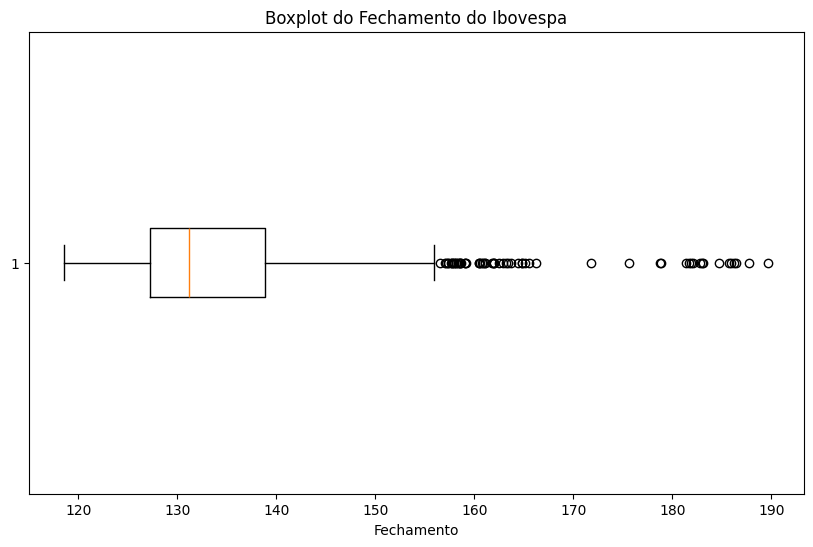

In [352]:
plt.figure(figsize=(10, 6))
plt.boxplot(ibovespa['fechamento'], vert=False)
plt.title('Boxplot do Fechamento do Ibovespa')
plt.xlabel('Fechamento')
plt.show()

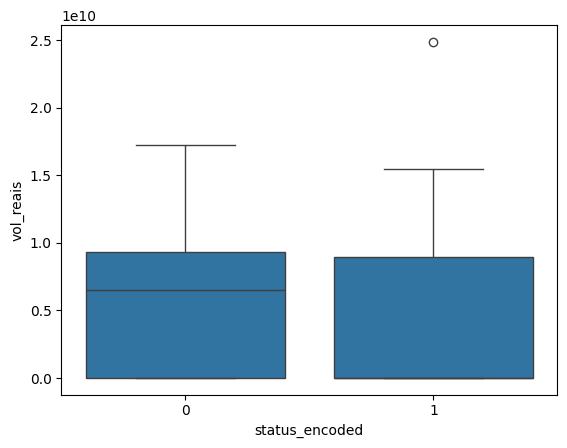

In [297]:
sns.boxplot(x="status_encoded", y="vol_reais", data=ibovespa)
plt.show()

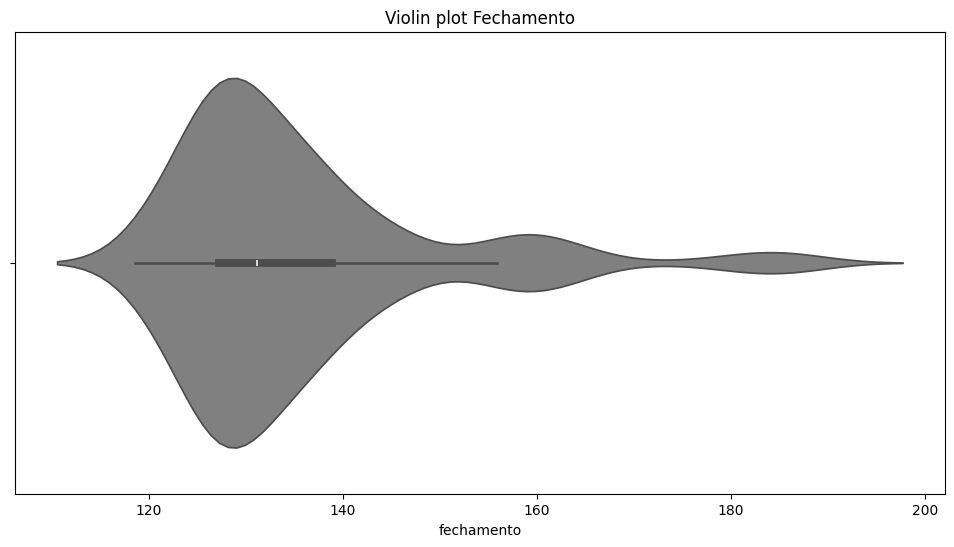

In [298]:
#Criando o subplot do boxplot, para configurarmos o tamanho
fig, axes = plt.subplots(figsize=(12,6))
sns.violinplot(x="fechamento", data=ibovespa, color="gray")
axes.set_title('Violin plot Fechamento')
plt.show()

In [300]:
# Transformando a coluna Data de objeto para data
ibovespa["data"] = pd.to_datetime(ibovespa["data"])
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,status,cotacao_dia_dolar,status_encoded
0,2026-02-19,186.020,188.687,185.928,188.534,9.240000e+09,1.35,alta,5.2109,0
1,2026-02-18,186.464,187.657,185.001,186.016,7.790000e+09,-0.24,baixa,5.2359,1
2,2026-02-13,187.766,187.766,183.662,186.464,1.159000e+10,-0.69,baixa,5.2196,1
3,2026-02-12,189.694,189.990,186.959,187.766,1.236000e+10,-1.02,baixa,5.2120,1
4,2026-02-11,185.936,190.561,185.936,189.699,1.164000e+10,2.03,alta,5.1836,0


In [301]:
# Quantidade de dados nulos por coluna
ibovespa.isnull().sum()

data                   0
abertura               0
maxima                 0
minima                 0
fechamento             0
vol_reais              0
variacao_percentual    0
status                 0
cotacao_dia_dolar      0
status_encoded         0
dtype: int64

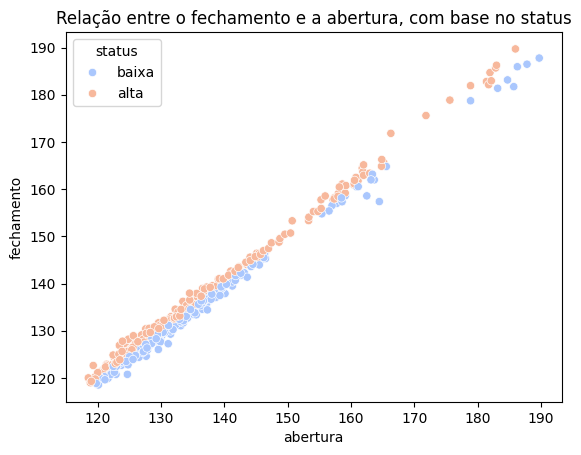

In [339]:

#Vamos verificar ambas coluna gerando um gráfico de dispersão
sns.scatterplot(x='abertura', y='fechamento', hue='status', data=ibovespa, palette='coolwarm')
plt.xlabel('abertura')
plt.ylabel('fechamento')
plt.title('Relação entre o fechamento e a abertura, com base no status')
plt.show()

In [303]:
# Validando a saída final da base
ibovespa.info()

<class 'pandas.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   data                 534 non-null    datetime64[us]
 1   abertura             534 non-null    float64       
 2   maxima               534 non-null    float64       
 3   minima               534 non-null    float64       
 4   fechamento           534 non-null    float64       
 5   vol_reais            534 non-null    float64       
 6   variacao_percentual  534 non-null    float64       
 7   status               534 non-null    str           
 8   cotacao_dia_dolar    534 non-null    float64       
 9   status_encoded       534 non-null    int64         
dtypes: datetime64[us](1), float64(7), int64(1), str(1)
memory usage: 41.8 KB


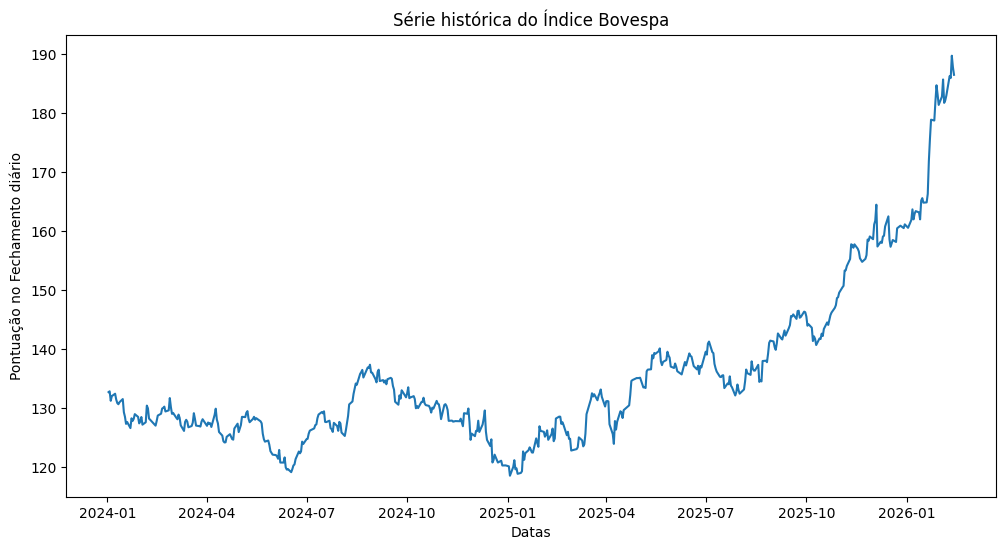

In [344]:
# Análise temporal (série histórica)
plt.figure(figsize=(12, 6))
plt.plot(ibovespa["data"], ibovespa["fechamento"])
plt.xlabel("Datas")
plt.ylabel("Pontuação no Fechamento diário")
plt.title("Série histórica do Índice Bovespa")
plt.show()

In [304]:
# Transformando a coluna vol_reais para logaritmo, para tentar reduzir a influência de outliers

ibovespa["vol_log"] = np.log(ibovespa["vol_reais"])

In [361]:
ibovespa = ibovespa.sort_values("data")

In [362]:
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,status,cotacao_dia_dolar,status_encoded,vol_log,target
533,2024-01-02,134.186,134.195,132.095,132.697,8440000.0,-1.11,baixa,4.9235,1,15.948493,0.0
532,2024-01-03,132.697,133.576,132.250,132.834,8700000.0,0.10,alta,4.9198,0,15.978834,1.0
531,2024-01-04,132.831,132.885,131.024,131.226,8970000.0,-1.21,baixa,4.8968,1,16.009396,0.0
530,2024-01-05,131.218,132.635,130.579,132.023,9200000.0,0.61,alta,4.8743,0,16.034714,0.0
529,2024-01-08,132.023,132.498,131.015,132.427,8500000.0,0.31,alta,4.8700,0,15.955577,1.0


## Testando o modelo SVC ❌

In [388]:
ibovespa["target_next"] = ibovespa["status_encoded"].shift(-1)

ibovespa["fechamento_lag1"] = ibovespa["fechamento"].shift(1)
ibovespa["vol_lag1"] = ibovespa["vol_log"].shift(1)
ibovespa["dolar_lag1"] = ibovespa["cotacao_dia_dolar"].shift(1)

ibovespa = ibovespa.dropna()

X = ibovespa[[
    "fechamento_lag1",
    "vol_lag1",
    "dolar_lag1"
]]

y = ibovespa["target_next"]

In [389]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

In [390]:
tscv = TimeSeriesSplit(n_splits=5)

In [391]:
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("Acurácia:", acc)

Acurácia: 0.5862068965517241
Acurácia: 0.40229885057471265
Acurácia: 0.4942528735632184
Acurácia: 0.4827586206896552
Acurácia: 0.5287356321839081


## Testando o modelo XGBoost ❌

In [384]:
ibovespa["target_next"] = ibovespa["status_encoded"].shift(-1)

ibovespa["fechamento_lag1"] = ibovespa["fechamento"].shift(1)
ibovespa["vol_lag1"] = ibovespa["vol_log"].shift(1)
ibovespa["dolar_lag1"] = ibovespa["cotacao_dia_dolar"].shift(1)

ibovespa = ibovespa.dropna()

X = ibovespa[[
    "fechamento_lag1",
    "vol_lag1",
    "dolar_lag1"
]]

y = ibovespa["target_next"]

tscv = TimeSeriesSplit(n_splits=5)

In [385]:
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("Acurácia:", acc)

Acurácia: 0.5568181818181818
Acurácia: 0.4431818181818182
Acurácia: 0.5
Acurácia: 0.48863636363636365
Acurácia: 0.6363636363636364


## Testando o modelo LogisticRegression ❌

In [369]:
X = ibovespa.drop(columns=["status", "data", "vol_reais", "variacao_percentual"])
y = ibovespa["status_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False  # importante em séries temporais
)

In [370]:
model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Avaliação
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred))

Acurácia: 1.0

Relatório de Classificação:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        92
           1       1.00      1.00      1.00        68

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



## Testando o modelo KNN  ✅

In [307]:
X = ibovespa.drop(columns=["status", "data", "vol_reais", "variacao_percentual"])
y = ibovespa["status_encoded"]

X_train = X.iloc[:-30]
X_test  = X.iloc[-30:]

y_train = y.iloc[:-30]
y_test  = y.iloc[-30:]

Testando o melhor neighbors K

In [308]:
for k in range(1, 21):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    pipeline.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipeline.predict(X_test))
    print(k, acc)

1 0.8
2 0.7666666666666667
3 0.8666666666666667
4 0.7666666666666667
5 1.0
6 1.0
7 1.0
8 0.7333333333333333
9 0.7666666666666667
10 0.7333333333333333
11 0.7666666666666667
12 0.7333333333333333
13 0.7333333333333333
14 0.7333333333333333
15 0.7333333333333333
16 0.7333333333333333
17 0.7333333333333333
18 0.7333333333333333
19 1.0
20 1.0


In [310]:
# Testando o modelo com k=3, para verificar a acurácia

pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=3))
    ])
pipeline.fit(X_train, y_train)
acc = accuracy_score(y_test, pipeline.predict(X_test))
print("Vizinhos: 3", "Acurácia:", acc)

Vizinhos: 3 Acurácia: 0.8666666666666667


# Testando o modelo Regressao Linear Minimo Escalado ❌

In [354]:
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,status,cotacao_dia_dolar,status_encoded,vol_log,target
533,2024-01-02,134.186,134.195,132.095,132.697,8440000.0,-1.11,baixa,4.9235,1,15.948493,0.0
532,2024-01-03,132.697,133.576,132.250,132.834,8700000.0,0.10,alta,4.9198,0,15.978834,1.0
531,2024-01-04,132.831,132.885,131.024,131.226,8970000.0,-1.21,baixa,4.8968,1,16.009396,0.0
530,2024-01-05,131.218,132.635,130.579,132.023,9200000.0,0.61,alta,4.8743,0,16.034714,0.0
529,2024-01-08,132.023,132.498,131.015,132.427,8500000.0,0.31,alta,4.8700,0,15.955577,1.0


In [355]:
X = ibovespa.drop(columns=["status", "data", "vol_reais", "variacao_percentual"])
y = ibovespa["status_encoded"]

X_train = X.iloc[:-30]
X_test  = X.iloc[-30:]

y_train = y.iloc[:-30]
y_test  = y.iloc[-30:]

scaler = MinMaxScaler()

scaler.fit(X_train)

x_train_scaled = scaler.transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [356]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [359]:
# Fazendo as previsões
y_pred = model.predict(x_test_scaled)

In [353]:
# Avaliando o modelo
MAE = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('MAE',MAE)
print('r²',r2)

MAE 0.6
r² -1.4999999999999991


# Testando o modelo Regressao Linear ❌

In [319]:
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,status,cotacao_dia_dolar,status_encoded,vol_log
533,2024-01-02,134.186,134.195,132.095,132.697,8440000.0,-1.11,baixa,4.9235,1,15.948493
532,2024-01-03,132.697,133.576,132.250,132.834,8700000.0,0.10,alta,4.9198,0,15.978834
531,2024-01-04,132.831,132.885,131.024,131.226,8970000.0,-1.21,baixa,4.8968,1,16.009396
530,2024-01-05,131.218,132.635,130.579,132.023,9200000.0,0.61,alta,4.8743,0,16.034714
529,2024-01-08,132.023,132.498,131.015,132.427,8500000.0,0.31,alta,4.8700,0,15.955577


In [321]:
X = ibovespa.drop(columns=["status", "data", "vol_reais", "variacao_percentual"])
y = ibovespa["status_encoded"]

X_train = X.iloc[:-30]
X_test  = X.iloc[-30:]

y_train = y.iloc[:-30]
y_test  = y.iloc[-30:]

In [322]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [323]:
y_pred = model.predict(X_test)
r_sq = model.score(X, y)

print('Coeficiente de Determinação (R²):', r_sq)

Coeficiente de Determinação (R²): 1.0


In [324]:
print('Intercepto:', model.intercept_)

Intercepto: 4.529709940470639e-14


# Testando o modelo RandomForestClassifier ❌

In [ ]:
ibovespa = ibovespa.sort_values("data")
ibovespa["target"] = ibovespa["status_encoded"].shift(-1)
ibovespa = ibovespa.dropna()

In [330]:
X = ibovespa.drop(columns=["status", "data", "status_encoded", "variacao_percentual", "target", "vol_reais"])
y = ibovespa["target"]

X_train = X.iloc[:-30]
X_test  = X.iloc[-30:]

y_train = y.iloc[:-30]
y_test  = y.iloc[-30:]

In [331]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=7))
])

In [333]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia: {accuracy:.4f}")
print("\nRelatório:")
print(classification_report(y_test, y_pred))

Acurácia: 0.4000

Relatório:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        18
         1.0       0.40      1.00      0.57        12

    accuracy                           0.40        30
   macro avg       0.20      0.50      0.29        30
weighted avg       0.16      0.40      0.23        30



c:\Users\renat\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\renat\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\renat\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave